# Multi Agent Refresher

## model loading

In [2]:
import os
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
# 1. Load variables from the .env file
load_dotenv()
OLLAMA_API_KEY = os.environ.get("OLLAMA_API_KEY")
GOOGLE_API_KEY = os.environ.get("GOOGLE_API_KEY")
TAVILY_API_KEY = os.environ.get("TAVILY_API_KEY")



llm = init_chat_model("google_genai:gemini-2.5-flash")
response = llm.invoke("What is the color of the sky answer in one word?")
print(response.content)


llm = init_chat_model("ollama:nemotron-3-super:cloud",base_url="https://ollama.com")
response = llm.invoke("What is the color of the sky answer in one word?")
print(response.content)


Blue
blue


## tool loading

In [4]:
from langchain.tools import tool

@tool
def square_root(x: float) -> float:
    """Calculates the square root of a number"""
    return x ** 0.5

@tool
def square(x: float) -> float:
    """Calculates the square of a number"""
    return x ** 2

@tool
def cube(x: float) -> float:
    """Calculates the cube of a number"""
    return x ** 3

## sub agents

In [5]:
from langchain.agents import create_agent
llm = init_chat_model("ollama:nemotron-3-super:cloud",base_url="https://ollama.com")

## create subagents

subagent_1 = create_agent(
    model=llm,
    tools=[square_root]
)

subagent_2 = create_agent(
    model=llm,
    tools=[square]
)

subagent_3 = create_agent(
    model=llm,
    tools=[cube]
)

## sub agent as a tool

In [6]:
from langchain.messages import HumanMessage

@tool
def call_subagent_1(x: float) -> float:
    """Call subagent 1 in order to calculate the square root of a number"""
    response = subagent_1.invoke({"messages":[HumanMessage(content=f"Calculate the square root of {x}")]})
    return response["messages"][-1].content

@tool
def call_subagent_2(x: float) -> float:
    """Call subagent 2 in order to calculate the square of a number"""
    response = subagent_2.invoke({"messages":[HumanMessage(content=f"Calculate the square of {x}")]})
    return response["messages"][-1].content

@tool
def call_subagent_3(x: float) -> float:
    """Call subagent 3 in order to calculate the cube of a number"""
    response = subagent_3.invoke({"messages":[HumanMessage(content=f"Calculate the cube of {x}")]})
    return response["messages"][-1].content



##  main agent

In [8]:
# Creating the main agent
llm2 = init_chat_model("google_genai:gemini-2.5-flash")
main_agent = create_agent(
    model=llm2,
    tools=[call_subagent_1, call_subagent_2, call_subagent_3],
    system_prompt="You are a helpful assistant who can call subagents to calculate the square root, square and cube of a given number."
)

## main agent graph

In [ ]:
# Generate the PNG bytes of the agent's internal architecture
png_bytes = main_agent.get_graph().draw_mermaid_png()

# Save the bytes into an actual image file
with open("main_agent_graph.png", "wb") as f:
    f.write(png_bytes)

print("Graph saved successfully as main_agent_graph.png!")


In [9]:
main_agent.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'model': Node(id='model', name='model', data=model_node(tags=None, recurse=True, explode_args=False, func_accepts={'runtime': ('N/A', <class 'inspect._empty'>)}), metadata=None), 'tools': Node(id='tools', name='tools', data=tools(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'runtime': ('N/A', <class 'inspect._empty'>)}, _tools_by_name={'call_subagent_1': StructuredTool(name='call_subagent_1', description='Call subagent 1 in order to calculate the square root of a number', args_schema=<class 'langchain_core.utils.pydantic.call_subagent_1'>, func=<function call_subagent_1 at 0x0000022970541620>), 'call_subagent_2': StructuredTool(name='call_subagent_2', description='Call subagent 2 in order to calculate the square of a number', args_schema=<class 'langchain_core.util

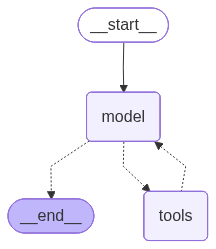

In [10]:
from IPython.display import Image, display
display(Image(main_agent.get_graph().draw_mermaid_png()))

## invoke main agent

In [11]:
question = "What is the square root of 456?"

response = main_agent.invoke({"messages":[HumanMessage(content=question)]})

In [12]:
from pprint import pprint

pprint(response)

{'messages': [HumanMessage(content='What is the square root of 456?', additional_kwargs={}, response_metadata={}, id='d1f12786-708e-4e7b-817e-d3c09a8d334d'),
              AIMessage(content='', additional_kwargs={'function_call': {'name': 'call_subagent_1', 'arguments': '{"x": 456}'}, '__gemini_function_call_thought_signatures__': {'b784717e-296f-493e-b93c-9caeedcc4c81': 'CpgCAQw51seZIJD6heizhg1FTvJ2oPCaR54/+vwYu+UajlburfGKnwr1cGFd26WL12pr/oGMPTGjVKWqF5RomIhZFj8xxX93OC5vFA54IE7Tye0ezjtIFbDIM/L6pe/iQ023pezlqZ9qGW1z0BTgRWausoccC0JHBwn46q0F/7JlOQ/eZaNCMpwjEbCNKK8HgZgrFBI5trieYH85j/yqyeXWypzgjxeUz/yHR9rNKQ4FvvS564IkEDgCEXog06Y61wxy1ydaXv/cBKVSVZC3wyskXe6SdPtAhCDnjfXYQidxVXeBuRnqTFNcBrNMNkL34xRtWyRx6p98wvRZamzh05hz/UKBFx5QJfLePCFMv6m0eO0B0tTeN9w/Zg=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ed447-8702-7c30-a97c-b39a9bfd1ce9-0', tool_calls=[{'name': 'call_subagent_1', 'args': {'x'

## main agent with memory

In [24]:
from langgraph.checkpoint.memory import InMemorySaver

memory_saver = InMemorySaver()
# Creating the main agent
llm2 = init_chat_model("google_genai:gemini-2.5-flash")
main_agent = create_agent(
    model=llm2,
    tools=[call_subagent_1, call_subagent_2, call_subagent_3],
    system_prompt="You are a helpful assistant who can call subagents to calculate the square root, square and cube of a given number.",
    checkpointer=memory_saver
)



In [ ]:
config = {"configurable": {"thread_id": "user_session_abc123"}}

# 5. Use the config when running the agent
response = main_agent.invoke(
    {"messages": [{"role": "user", "content": "What is the square root of square of 16?"}]},
    config=config
)


response = main_agent.invoke({"messages":[HumanMessage(content=question)]})

In [16]:
from pprint import pprint
pprint(response)

{'messages': [HumanMessage(content='What is the square root of square of 16?', additional_kwargs={}, response_metadata={}, id='0360fcd3-3d81-4460-8bed-43f9ee82128a'),
              AIMessage(content='', additional_kwargs={'function_call': {'name': 'call_subagent_2', 'arguments': '{"x": 16}'}, '__gemini_function_call_thought_signatures__': {'5a8003ad-79e7-4e69-a4fb-839fc9c3f651': 'CuYDAQw51sdSlfd+JZq3l9RvYTscOq4oiV78UnW17cVvJ4rEb/yvxBgpEPblRdN9TaBsALALczGsBSlDkok8BForfQ24xgqr8xEJwZsbY/5bmRNxKEZApYgVVkQiMHrQ18ixVHQuo9h4E6+W6XfKCLC7Y0gcC+fEZLZy2l2YgM3r94TqmIGo926TRftJJCnp484eKS5ofjb8+GORCwRiwfgq4nlKXO0oJKG46TH7jiuwiW3lKuyaePJzn8iwLxOwrf+1oSgw7KRAkW/WyUu592930u4tncM6rIjheZ/3yllX6ZEW90clac1peyatZHVbHEkFbtAJKrphMahmfIeBEzClbvn3s4+sr0lAV4LfATyept3wdQPiPu+MbO6LI9ZFRfNbSiKqo6WNLBBiaMfDn/atfrSZqMKTP6newgP9yiF1puik/9uK+ByBNv0ZBwrj0HKyPpEHz79gZwkgevB2JXdrOGsMB7gsyCvs657+XYbXz/d07KC08SA9JCf+k3+rjHvaIF16fRryWDw8Ih/1H7RZ1RgwWaNJlEQ2Y3S9gP6RP22qpGhVD2VJtUA8VHrNSEhkUkB8/BG0iw98leh0jdSk9x5KwizavfijpauEH

In [ ]:
pprint(response["messages"][-1].content)

## state visulaiuzation

In [18]:
# Assuming 'response' is the variable holding the dictionary you shared
messages = response.get("messages", [])

print("=" * 60)
print("🔍 AGENT EXECUTION TRACE (STEP-BY-STEP)")
print("=" * 60)

for idx, msg in enumerate(messages, 1):
    msg_type = type(msg).__name__
    print(f"\n[STEP {idx}] Sender Type: {msg_type}")
    
    # 1. Handle the User Prompt
    if msg_type == "HumanMessage":
        print(f"👤 User Input: '{msg.content}'")
        
    # 2. Handle Agent Decisions (Calling Tools)
    elif msg_type == "AIMessage":
        # Check if the agent decided to call tools
        if getattr(msg, "tool_calls", None):
            print("🤖 Main Agent Decision: Needs helper subagents.")
            for call in msg.tool_calls:
                print(f"   👉 Action: Calling tool '{call['name']}'")
                print(f"   👉 Arguments sent to subagent: {call['args']}")
        # Check if the agent is giving the final text response
        elif msg.content:
            # Sometimes content is a list of blocks, sometimes a direct string
            if isinstance(msg.content, list):
                text_content = next((block['text'] for block in msg.content if block.get('type') == 'text'), "")
                print(f"🏆 Final Answer from Agent: {text_content}")
            else:
                print(f"🏆 Final Answer from Agent: {msg.content}")
        else:
            print("🤖 Main Agent: Thinking silently / routing data...")

    # 3. Handle Subagent Outputs
    elif msg_type == "ToolMessage":
        print(f"🛠️  Subagent Response (From tool '{getattr(msg, 'name', 'Unknown')}'):")
        print(f"   📥 Result: {msg.content}")

    print("-" * 40)


🔍 AGENT EXECUTION TRACE (STEP-BY-STEP)

[STEP 1] Sender Type: HumanMessage
👤 User Input: 'What is the square root of square of 16?'
----------------------------------------

[STEP 2] Sender Type: AIMessage
🤖 Main Agent Decision: Needs helper subagents.
   👉 Action: Calling tool 'call_subagent_2'
   👉 Arguments sent to subagent: {'x': 16}
----------------------------------------

[STEP 3] Sender Type: ToolMessage
🛠️  Subagent Response (From tool 'call_subagent_2'):
   📥 Result: The square of 16.0 is 256.0.
----------------------------------------

[STEP 4] Sender Type: AIMessage
🤖 Main Agent Decision: Needs helper subagents.
   👉 Action: Calling tool 'call_subagent_1'
   👉 Arguments sent to subagent: {'x': 256}
----------------------------------------

[STEP 5] Sender Type: ToolMessage
🛠️  Subagent Response (From tool 'call_subagent_1'):
   📥 Result: The square root of 256.0 is 16.0.
----------------------------------------

[STEP 6] Sender Type: AIMessage
🏆 Final Answer from Agent: The

In [ ]:
# List all checkpoints saved across all namespaces for this thread
checkpoints = list(memory_saver.list(config))

for cp in checkpoints:
    ns = cp.config["configurable"].get("checkpoint_ns", "")
    if ns: # If it has a namespace, it belongs to a subagent/subgraph
        print(f"Subagent Namespace: {ns}")
        print(f"State Values: {cp.metadata}\n")

In [34]:
current_states.values.get("messages", [])

[HumanMessage(content='What is the square root of square of 16?', additional_kwargs={}, response_metadata={}, id='31112c41-c64d-495d-8839-f46974226434'),
 HumanMessage(content='What is the square root of square of 16?', additional_kwargs={}, response_metadata={}, id='9c209662-a91a-4408-986c-5570579e81b0'),
 AIMessage(content='', additional_kwargs={'function_call': {'name': 'call_subagent_2', 'arguments': '{"x": 16}'}, '__gemini_function_call_thought_signatures__': {'4153ef3f-4c35-4f6b-9e8e-30fe50310896': 'Cr4FAQw51sfzVxbo35NcRTxIAmA83ETqMnkGadSUwdMc9L2pv7AStChYG3mkDZnX5U7zE2hePdkIoVXb8jdNNQ0jrSKt8IMKREGUX82lxDobsflDRp4PT0e9esUX14MENSeFsFLViFEJxxXs4/maAVTB365NZiFDcWO9ZbGg5YEx32iVW+7KXW805Wop/DJ7KeZLEdYd4c3C7TeZeCmesTtr8+CgypB/xbTNimGHA2M/CBvob4u4lxCVxndFEh+te3SI1ZwJNw2m2h+/Tfzpw0IDbqQBnQDC3NvJexIZRSF3QfFk+tMYhy00YVp/saKsOsvlXWzwn9mNugbWD8ULglef2MEA4n/3XQ61sBFK85NUUEeRB2Ms/4JSkMdD3w9uqQXbRi/+bAb2M6Nn9QbW8J/PO/Gdvyq1rjLZ8RIKkYFEUegw+4iGa/rrX9vMVzvkqNWl8s/hHleeUQX5dy4zdY7uuv9Q48d4s1na4zPLp